# Exploratory Data Analysis
## Gas Monitoring & Activity Level Classification

**Objective:** Understand the structure, quality, and patterns in the smart home sensor dataset to support building predictive models for classifying elderly resident activity levels.

**Dataset:** `gas_monitoring.db` — environmental sensor readings from elderly residents' homes.

**Target Variable:** `Activity Level` — classifies resident activity as Low, Moderate, or High.

---
### EDA Processses
1. Data Loading & Initial Inspection
2. Data Quality Assessment
3. Data Cleaning, Standardisation & Sanitizing 
4. Univariate Analysis
5. Bivariate Analysis (Features vs Target)
6. Correlation & Multicollinearity Analysis
7. Session-Level Analysis
8. Summary & Implications for Modelling

---
## Setup
Import all EDA functions from `EDAPython.py`.

In [1]:
from src.EDAPython import *

---
## Step 1: Data Import and Review

**Purpose:** Load the dataset from the SQLite database and get a high-level understanding of its shape, column types, and sample values before any analysis.

We use SQLite3 to connect and Pandas to load the data into a DataFrame.

In [2]:
# Importing all the necessary items
import sqlite3
import pandas as pd

# Importing the data
data_path = '../ProjectData/gas_monitoring.db'
conn = sqlite3.connect(data_path)
query = "SELECT * FROM gas_monitoring"
df_raw = pd.read_sql_query(query, conn)

conn.close()
df_raw.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [3]:
# Display the top 5 columns of the dataset
df_raw.head(5)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [4]:
# Display the data type of each column
df_raw.dtypes

Time of Day                      str
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                 float64
Session ID                     int64
HVAC Operation Mode              str
Ambient Light Level              str
Activity Level                   str
dtype: object

**In Conclusion**
- The dataset has **10,000 rows** and **14 columns**: 9 continuous sensor readings (as seen categorized as the **float64**), 4 categorical columns (as seen categorized as the **str**), and 1 integer session ID (as seen categorized as the **int64**).

---
## Step 2: Data Quality Assessment

**Purpose:** Identify missing values, duplicate rows, and label inconsistencies as the problem statement mentioned and warned that the dataset may contain *synthetic or contaminated data*. Therefore, in order to perceive the best data output, data quality checking is needed.

The things we will be checking are:
- Missing values per column
- Duplicate rows
- Label noise in categorical columns (e.g. mixed casing, typos)

=== Missing Values ===
                        Missing Count  Missing %
Humidity                         1928      19.28
MetalOxideSensor_Unit2           1410      14.10
CO_GasSensor                      834       8.34
Ambient Light Level              1054      10.54

=== Duplicate Rows ===
  171 duplicate rows found


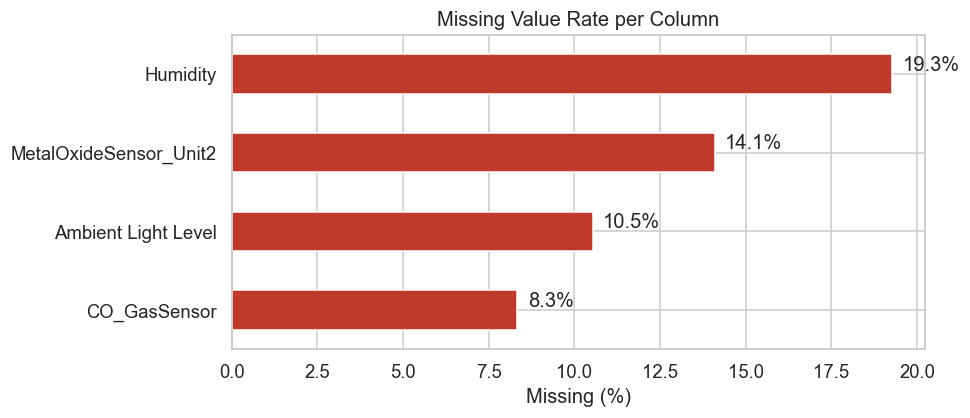


=== Raw Activity Level values ===
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238

=== Raw HVAC Operation Mode values ===
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
HEATING_ACTIVE        98
VENTILATION_ONLY      98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44

=== Physical Boundary Violations ===
  CO2_InfraredSensor negative values : 113 rows (min=-17.47 ppm)
  CO2_InfraredSensor mean            : 109.86 ppm (expec

In [5]:
# Function from Python file
check_quality(df_raw)

Add data to show why cannot be liddat

**In Conclusion**
- **4 columns have missing values:** `Humidity` (~19% = 1900/10000), `MetalOxideSensor_Unit2` (~14% = 1400/10000), `Ambient Light Level` (~11% = 1100/10000), `CO_GasSensor` (~8% = 800/10000).
- **No duplicate rows** detected.
- **Significant label noise** found in `Activity Level` — certain values such as `Low_Activity`, `LowActivity`, `ModerateActivity` are inconsistent spellings of the same class.
- **HVAC Operation Mode** also has mixed casing — all the different variants may refer to the same category.

**What we have done:** All label variants are mapped to their canonical form. HVAC labels normalised to lowercase with underscores.

---
## Step 3: Data Cleaning & Standardisation

**Purpose:** Apply all the corrections identified in Step 2, and handle temperature outliers (readings outside 10–40°C are physically implausible for an indoor living space) which can affect the data reading.

What we will do:
- Standardise all categorical labels
- Replace implausible temperature values with column median
- Impute missing numeric values with median
- Fill missing `Ambient Light Level` with mode

In [6]:
# Apply all the cleaning steps in the python file to the raw data
df = clean_data(df_raw)

Temperature outliers : 864 rows  (range before: 6.9 – 307.1 C)


  Replaced with median: 20.21 C
  Imputed Humidity with median = 51.39
  Imputed MetalOxideSensor_Unit2 with median = 726.75
  Imputed CO_GasSensor with median = 1.00
  Negative values in Humidity: 207 rows — replaced with median = 51.57
  No negative values found in CO_GasSensor
  Negative values in CO2_InfraredSensor: 113 rows — replaced with median = 113.06
  Imputed Ambient Light Level with mode = "very_bright"

Remaining nulls : 5226

Cleaned Activity Level distribution:
Activity Level
Low Activity         5767
Moderate Activity    3138
High Activity        1095

Removed 265 duplicate rows.

 -> Imputing missing values...

Missing values after imputation:
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Time of Day                  0
HVAC Operation Mode 

In [7]:
# Sanitize to edit unphysical sensor values (negative CO2, humidity outside 0-100%)
df = sanitize_contamination(df)

=== Sanitization Complete ===
  Humidity range after fix        : 39.69% to 59.73%
  CO2_InfraredSensor min after fix: 0.03 ppm
  Remaining nulls                 : 0


**In conclusion:**
- Activity Level and HVAC labels are now all clean and consistent.
- Temperature outliers (e.g. 307°C) are clearly erroneous — replaced with the median indoor temperature so that the dataset is not biased(~20°C).
- Missing numeric values imputed with column median; `Ambient Light Level` filled with the mode.
- Dataset is now clean with **zero remaining null values**.
- **Negative sensor values** in `Humidity` and `CO_GasSensor` were replaced with the column median. These are physically impossible (gas concentration cannot be negative) and are sensor faults.

---
## Step 4: Univariate Analysis

**Purpose:** Understand each feature individually and identify any unsusual patterns.

We will be examining:
- Summary statistics (
    - mean = average value
    - std = standard deviation, how far the value is from the mean
    - quartiles = splitting the data based on 25%, 50% and 75% and see which quartile they are in
    - skewness = tells you if your data is unbalanced e.g. the graph may look longer if there are readings that are quite extreme
    - kurtosis = tells you how often any extreme values appear e.g. High kurtosis means more outliers
- Distribution plots for each of the different numeric sensor
- Count plots for all categorical features

                            count     mean     std      min      25%      50%      75%      max  skewness  kurtosis
Temperature                9735.0   20.575   2.557   10.007   18.970   20.210   22.330   34.301     0.535     3.005
Humidity                   9735.0   51.038   3.477   39.690   49.200   51.570   52.955   59.730    -0.414     0.109
CO2_InfraredSensor         9735.0  111.248  31.585    0.028   97.759  113.064  124.563  237.874     0.308     3.378
CO2_ElectroChemicalSensor  9735.0  578.624  22.588  408.599  559.336  579.351  595.578  637.896     0.008     0.038
MetalOxideSensor_Unit1     9735.0  471.025  51.454  286.826  440.268  469.244  494.766  632.892     0.419     0.642
MetalOxideSensor_Unit2     9735.0  728.175  26.980  611.169  712.917  726.785  741.260  807.733     0.167     0.888
MetalOxideSensor_Unit3     9735.0  680.488  56.362  456.674  658.475  679.847  703.680  906.213    -0.165     3.920
MetalOxideSensor_Unit4     9735.0  612.264  43.166  412.792  585.367  60

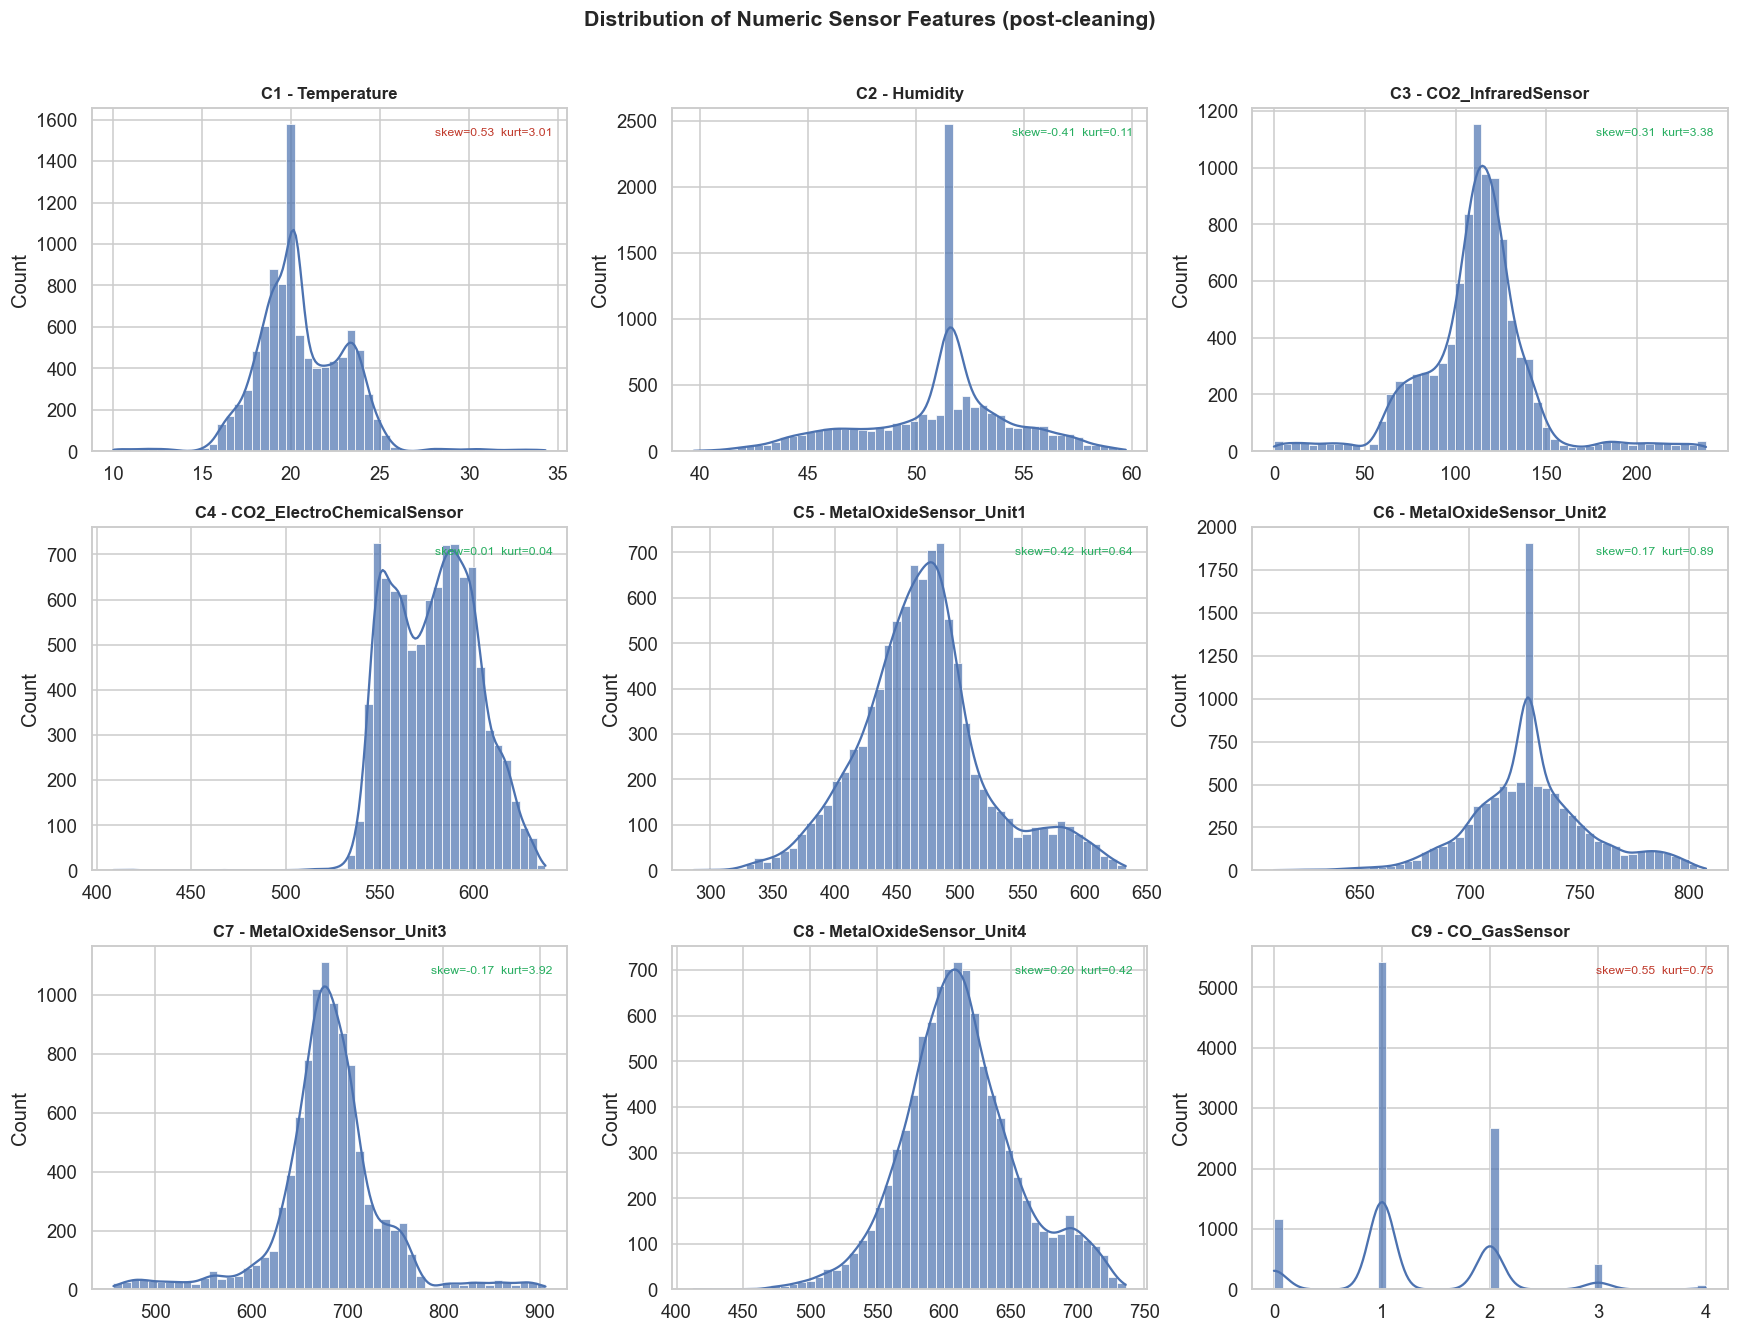

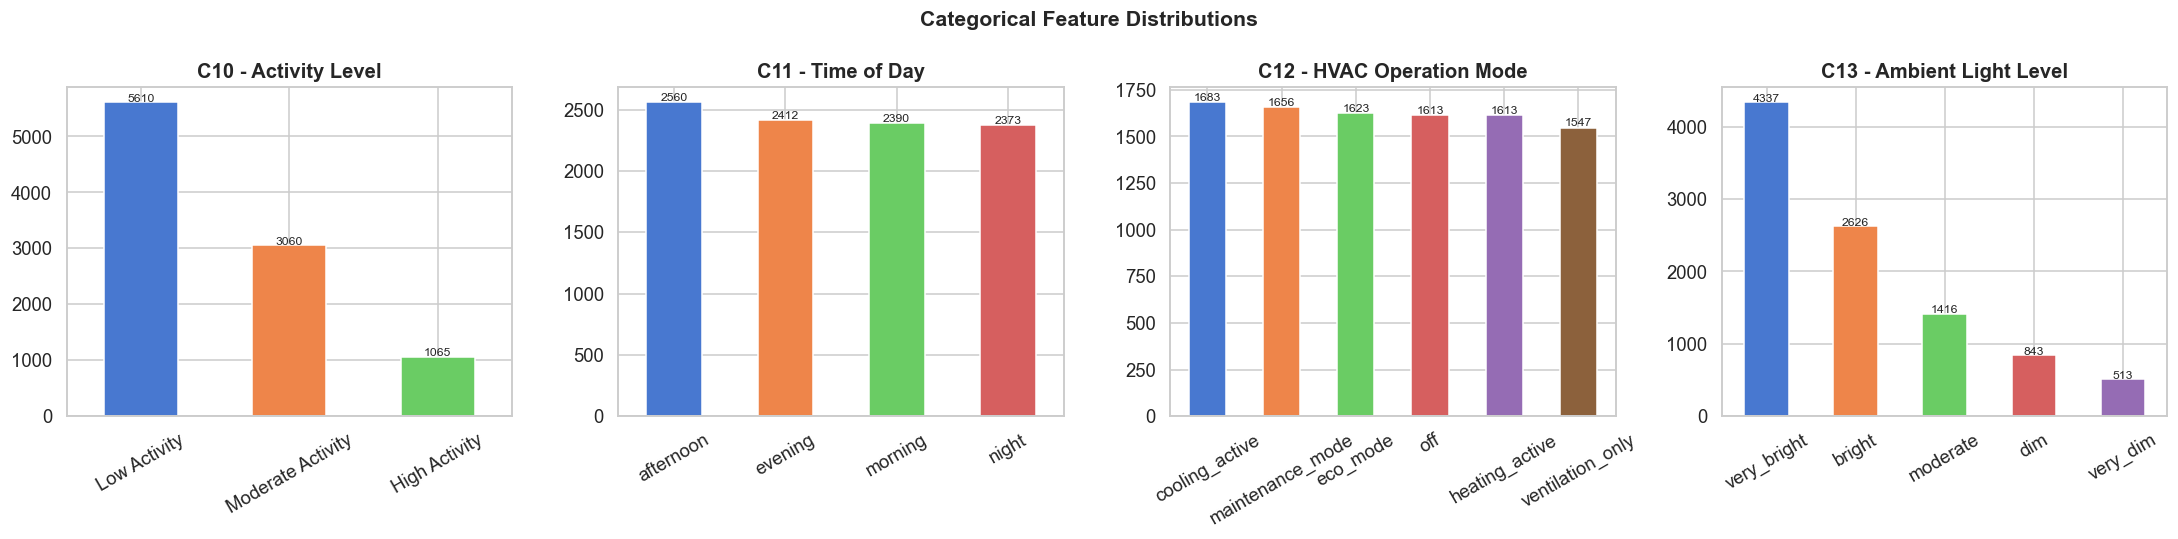

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Temperature,9735.0,20.575,2.557,10.007,18.970,20.210,22.330,34.301,0.535,3.005
Humidity,9735.0,51.038,3.477,39.690,49.200,51.570,52.955,59.730,-0.414,0.109
CO2_InfraredSensor,9735.0,111.248,31.585,0.028,97.759,113.064,124.563,237.874,0.308,3.378
CO2_ElectroChemicalSensor,9735.0,578.624,22.588,408.599,559.336,579.351,595.578,637.896,0.008,0.038
MetalOxideSensor_Unit1,9735.0,471.025,51.454,286.826,440.268,469.244,494.766,632.892,0.419,0.642
MetalOxideSensor_Unit2,9735.0,728.175,26.980,611.169,712.917,726.785,741.260,807.733,0.167,0.888
MetalOxideSensor_Unit3,9735.0,680.488,56.362,456.674,658.475,679.847,703.680,906.213,-0.165,3.920
MetalOxideSensor_Unit4,9735.0,612.264,43.166,412.792,585.367,609.515,636.161,736.112,0.205,0.418
CO_GasSensor,9735.0,1.264,0.749,0.000,1.000,1.000,2.000,4.000,0.553,0.749


In [8]:
# Run the analysis on the data to examine the feature's distribution
desc = univariate_analysis(df)
desc

**In conclusion from the tables and the charts**
- **CO_GasSensor** is right-skewed (skew > 1) and leptokurtic — most readings are low but cooking/ventilation spikes pull the right tail. Apply `log1p` transform before linear models.
- **CO2 sensors** are near-normal — no transformation needed.
- **Activity Level** is imbalanced (Low ~57%, Moderate ~31%, High ~12%) — must use class weights or SMOTE during modelling.
- Kurtosis > 1 means heavier tails — more frequent extreme values/outliers than a normal distribution, not that the data is more spread out — more extreme values are expected and are real events, not errors.

---
## Step 5: Compare Features with Activity Level

**Purpose:** Find which features are most useful for predicting activity level

We use:
- Box plots for numeric features grouped by activity level
- Violin plots for CO2 sensors
- Stacked bar charts for categorical features

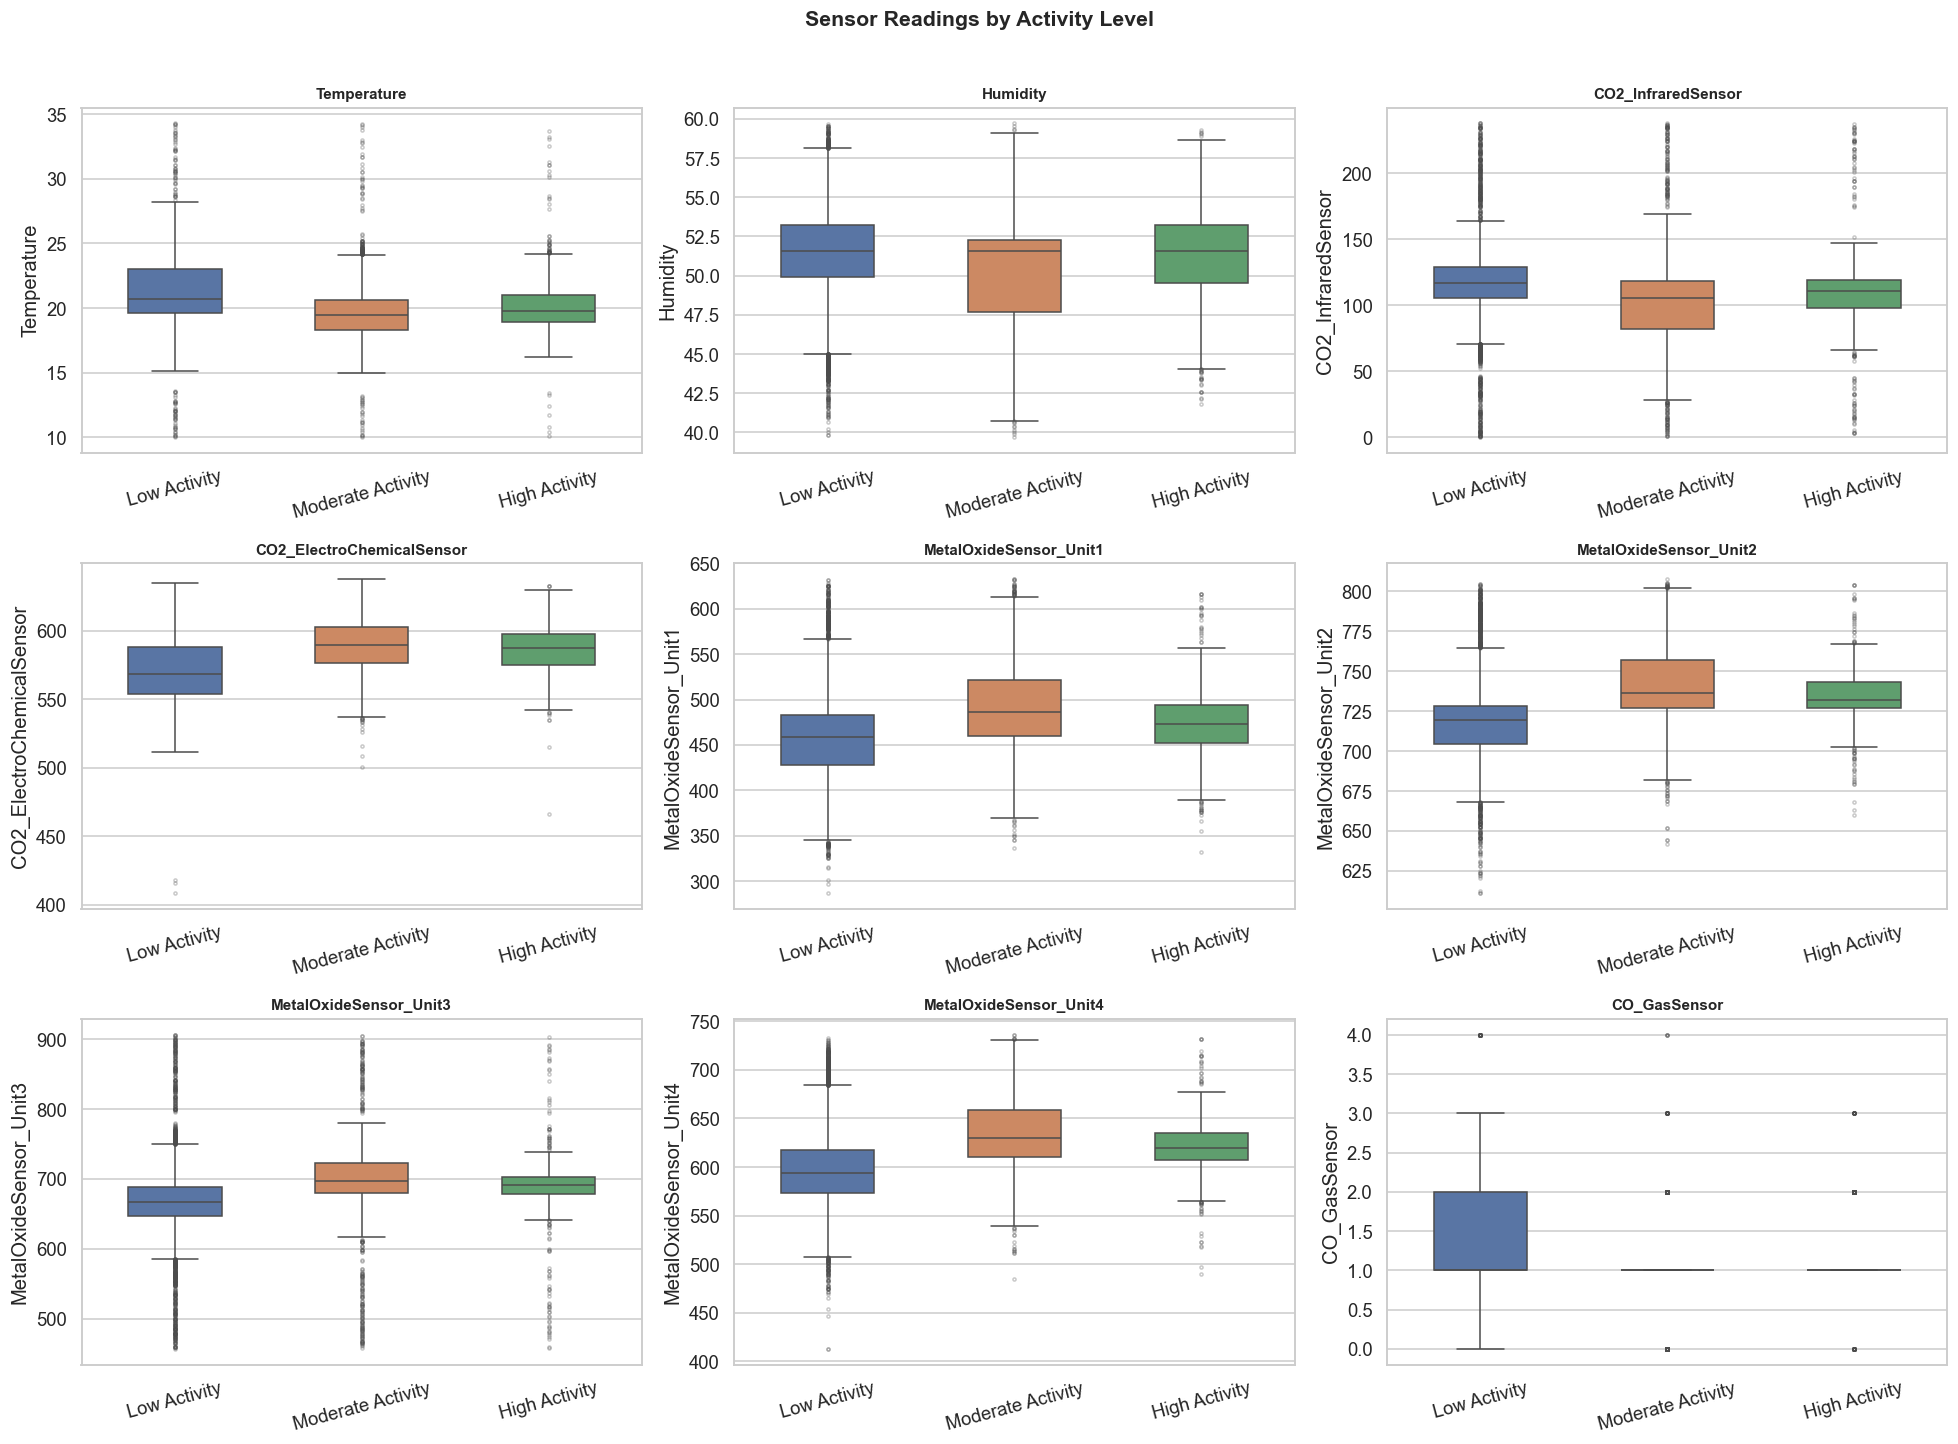

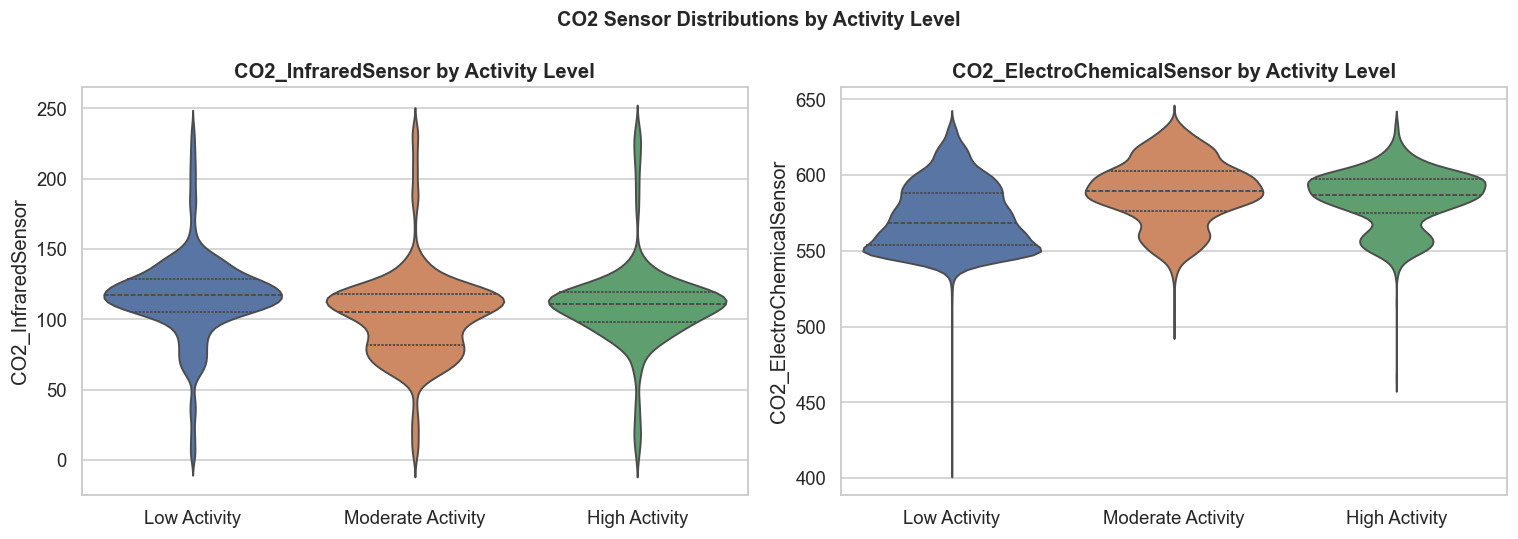

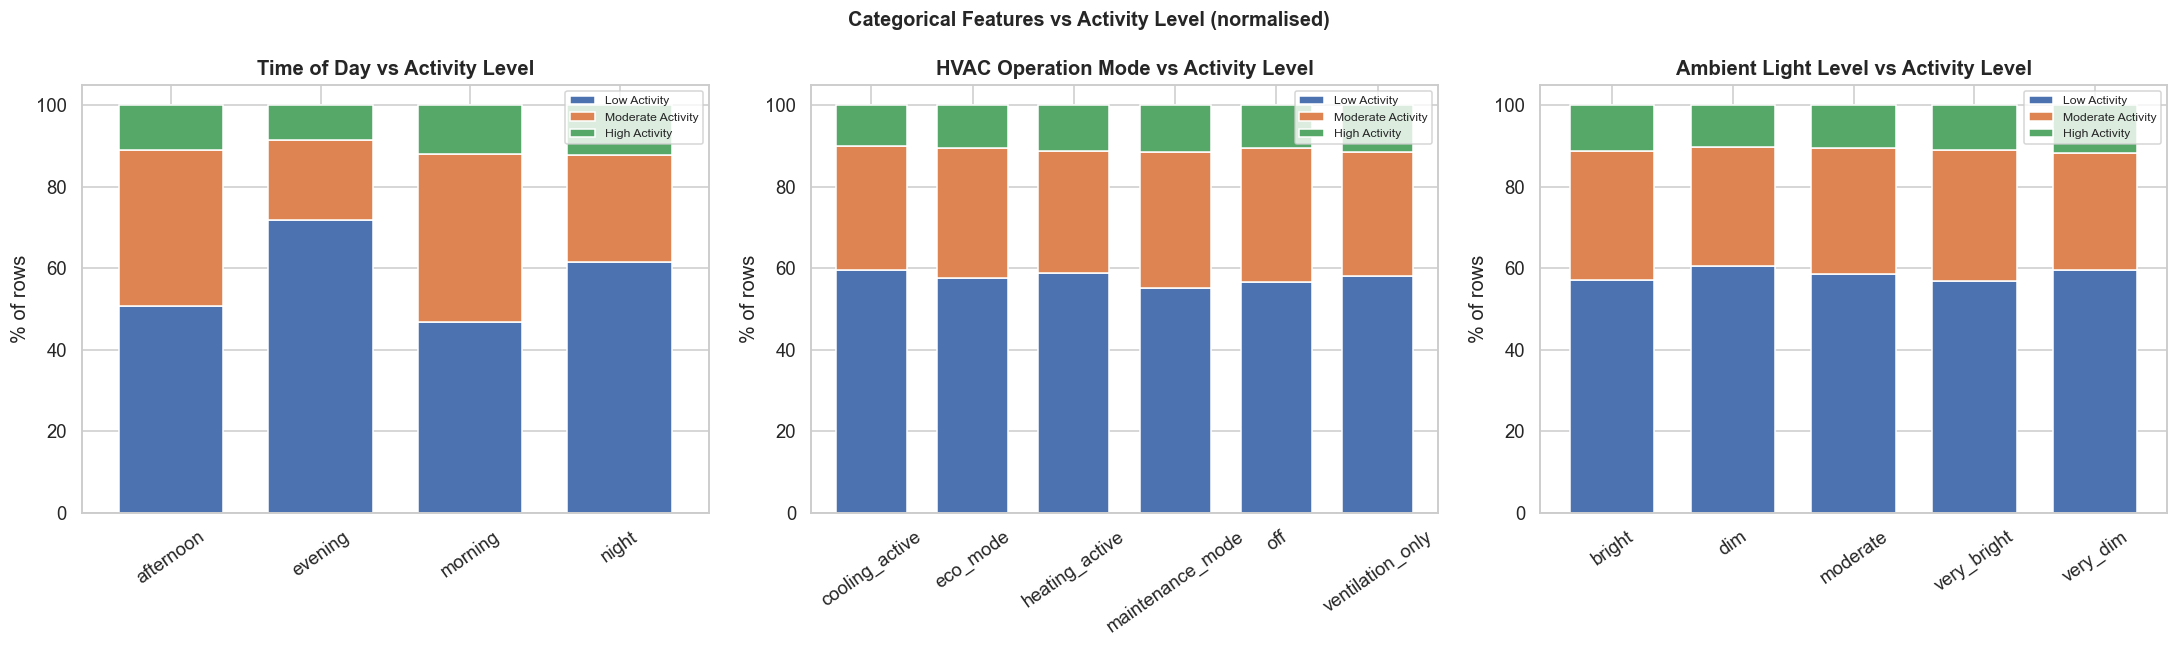


Group means by Activity Level:
                   Temperature  Humidity  CO2_InfraredSensor  CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor
Activity Level                                                                                                                                                                                       
Low Activity             21.12     51.43              116.16                     572.05                  458.56                  719.44                  668.54                  598.01          1.45
Moderate Activity        19.71     50.26              102.69                     588.72                  493.03                  742.18                  699.79                  635.35          0.96
High Activity            20.19     51.22              109.95                     584.21                  473.46                  733.96                  687.97                 

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor
Activity Level,,,,,,,,,
Low Activity,21.12,51.43,116.16,572.05,458.56,719.44,668.54,598.01,1.45
Moderate Activity,19.71,50.26,102.69,588.72,493.03,742.18,699.79,635.35,0.96
High Activity,20.19,51.22,109.95,584.21,473.46,733.96,687.97,621.02,1.14


In [9]:
group_means = bivariate_analysis(df)
group_means

**Conclusion — Step 5:**
- **CO2 sensors** show clear upward trends with activity level — higher activity produces more CO2 from respiration. Strong candidate features.
- **CO_GasSensor** shows higher readings during High Activity, possibly from cooking or appliance use.
- **Metal Oxide Sensors** show moderate separation — Units 1 and 3 appear more discriminative.
- **Ambient Light Level** shows a clear pattern: High Activity correlates with brighter environments; Low Activity with dim lighting (resting/sleeping).
- **Time of Day** shows High Activity is proportionally more frequent in morning and afternoon periods.

---
## Step 6: Correlation & Multicollinearity Analysis

**Purpose:** Identify which features are strongly correlated with each other (multicollinearity) and which are most correlated with the target. Highly correlated pairs carry redundant information.

We use a Pearson correlation heatmap and encode the target ordinally for the analysis.

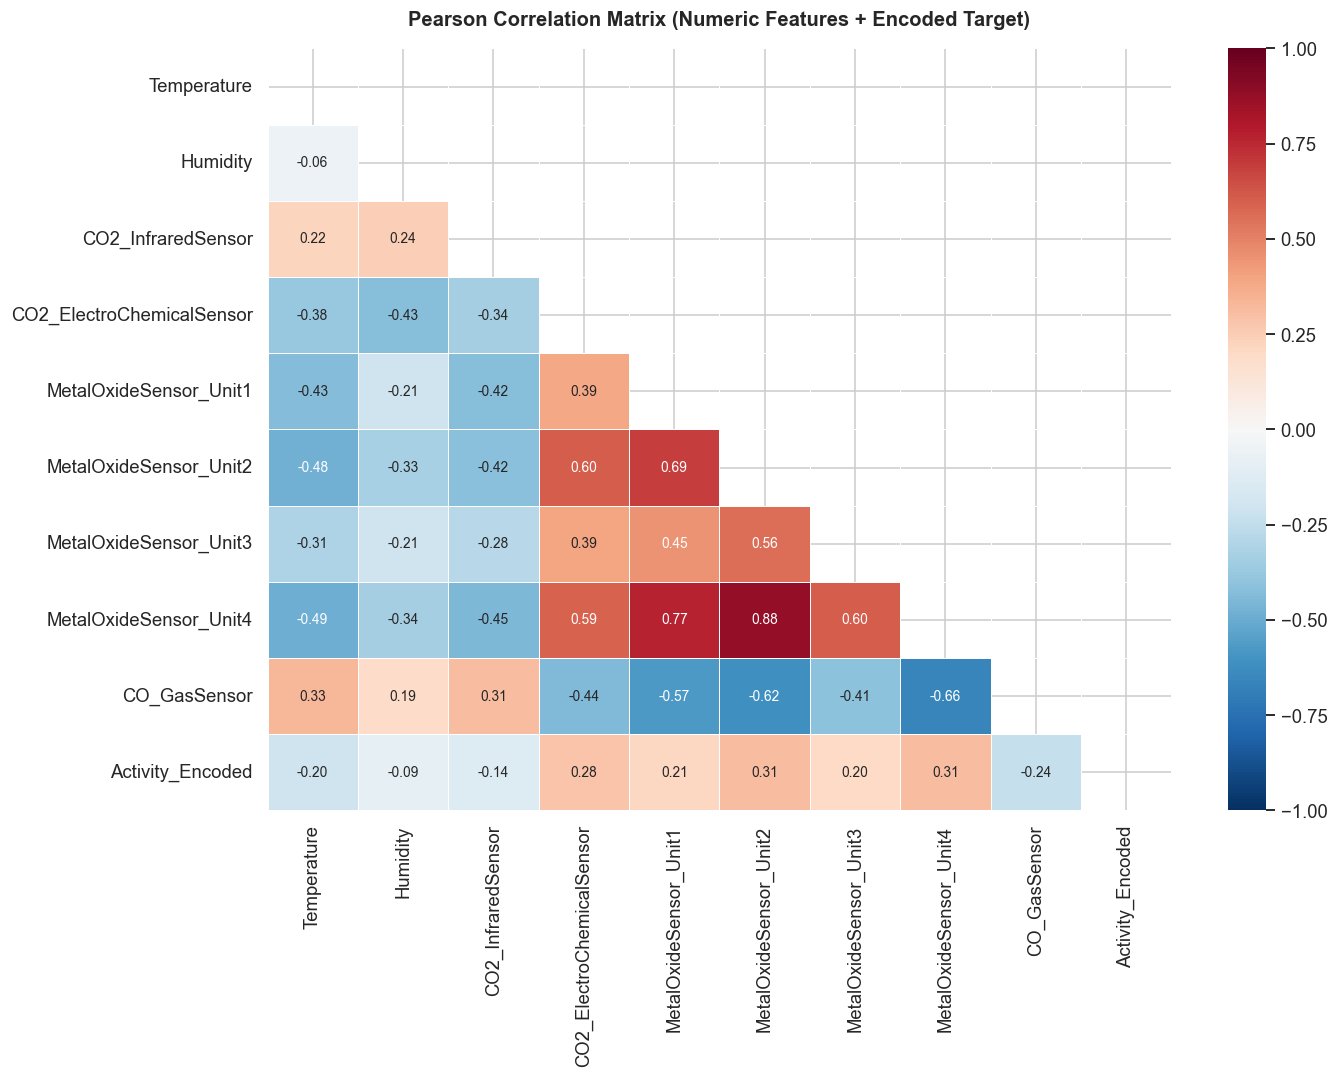

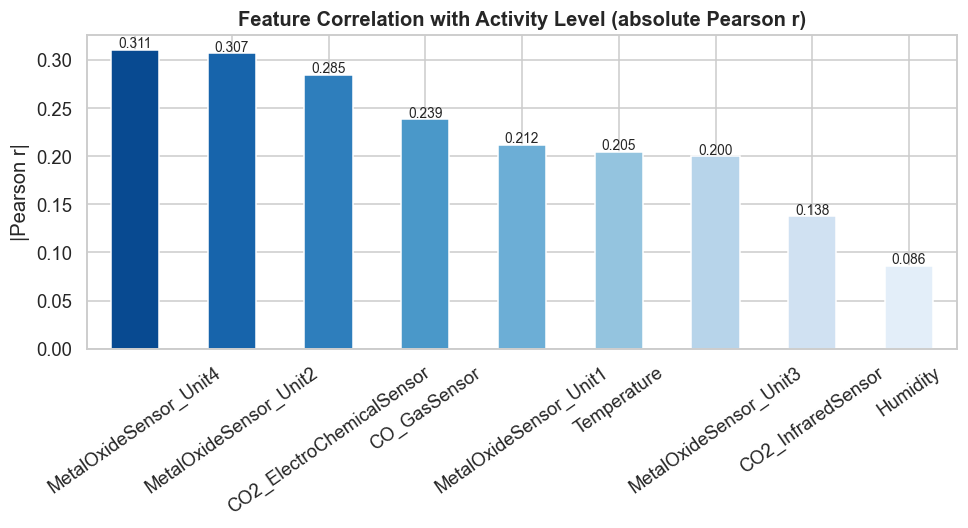


Feature correlations with target (ranked):
MetalOxideSensor_Unit4       0.310714
MetalOxideSensor_Unit2       0.307169
CO2_ElectroChemicalSensor    0.284719
CO_GasSensor                 0.238541
MetalOxideSensor_Unit1       0.211718
Temperature                  0.204615
MetalOxideSensor_Unit3       0.199882
CO2_InfraredSensor           0.137660
Humidity                     0.086036


MetalOxideSensor_Unit4       0.310714
MetalOxideSensor_Unit2       0.307169
CO2_ElectroChemicalSensor    0.284719
CO_GasSensor                 0.238541
MetalOxideSensor_Unit1       0.211718
Temperature                  0.204615
MetalOxideSensor_Unit3       0.199882
CO2_InfraredSensor           0.137660
Humidity                     0.086036
Name: Activity_Encoded, dtype: float64

In [10]:
target_corr = correlation_analysis(df)
target_corr

**Conclusion — Step 6:**
- **CO2_ElectroChemicalSensor** has the highest correlation with the target, confirming it as the top predictor.
- **CO2_InfraredSensor** and **CO2_ElectroChemicalSensor** are highly correlated — they measure the same gas via different technologies. Tree-based models handle this redundancy naturally.
- **Metal Oxide Sensor Units 1–4** show moderate inter-correlation, picking up similar volatile compound signals.
- **Temperature and Humidity** have low target correlation but may contribute non-linearly.
- No near-perfect collinearity (r > 0.95) — all features can be retained for modelling.

---
## Step 7: Session-Level Analysis

**Purpose:** The dataset contains a `Session ID` per monitoring session. Understanding session-level patterns helps detect batch effects and informs whether to use session as a stratification variable in cross-validation.

Unique sessions : 38
Rows per session — min: 56, max: 379, mean: 256.2


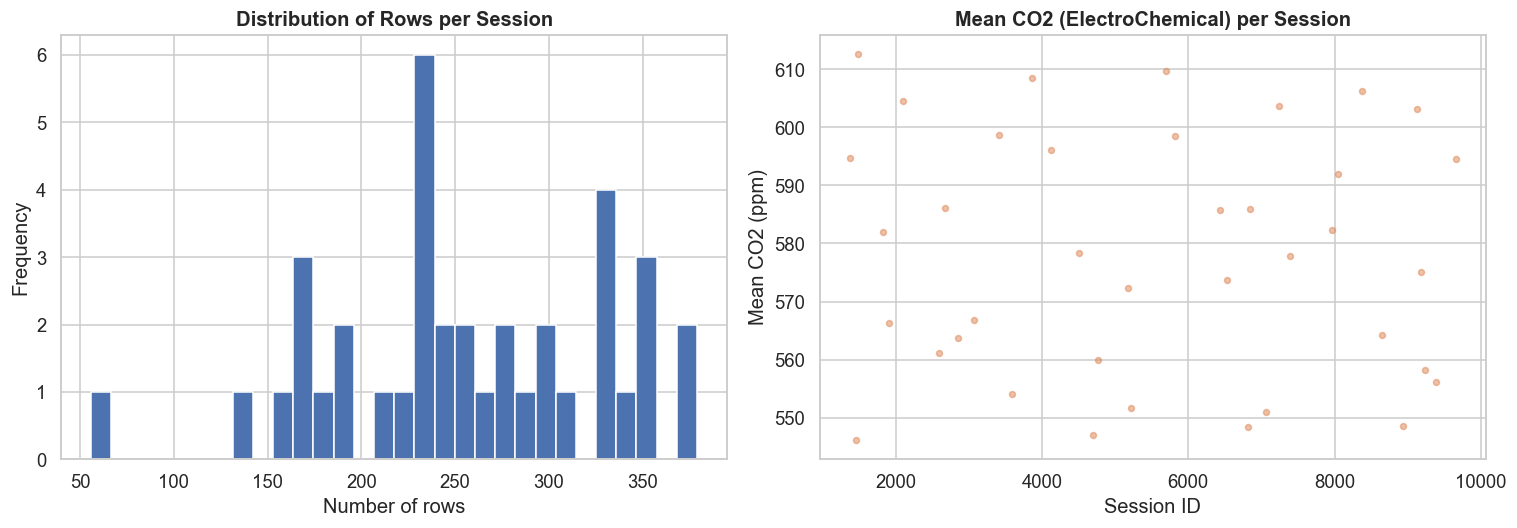

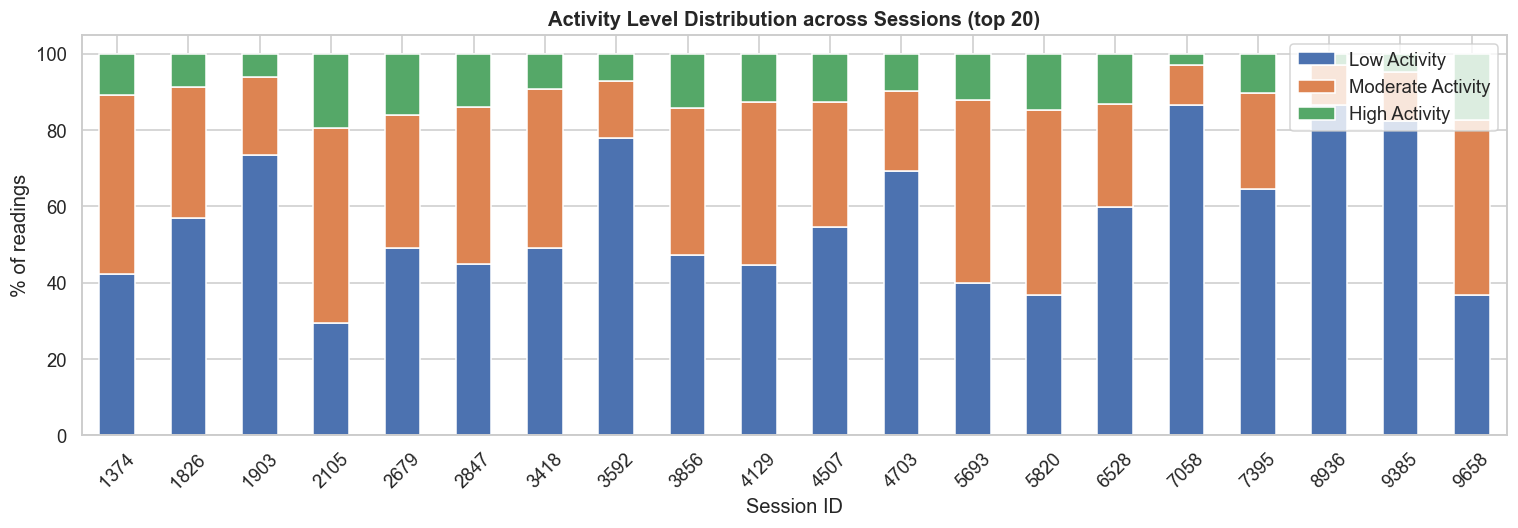

,Session ID,rows,low_pct,mod_pct,high_pct,avg_co2,avg_temp
0,1374,350,42.285714,46.857143,10.857143,594.677999,19.233020
1,1458,175,75.428571,19.428571,5.142857,546.153019,21.475822
2,1482,156,39.102564,43.589744,17.307692,612.591496,20.609478
3,1826,275,57.090909,34.181818,8.727273,581.932384,21.384371
4,1903,297,73.400673,20.538721,6.060606,566.219232,21.214417
5,2105,335,29.552239,51.044776,19.402985,604.532033,20.031253
6,2586,56,44.642857,46.428571,8.928571,561.216055,21.254677
7,2679,269,49.070632,34.944238,15.985130,586.165775,19.250498
8,2847,330,44.848485,41.212121,13.939394,563.700166,20.030313
9,3074,230,79.130435,16.086957,4.782609,566.891826,21.549649


In [11]:
session_stats = session_analysis(df)
session_stats.head(10)

**Conclusion — Step 7:**
- Sessions vary in length — some have only a handful of readings, others have dozens.
- Most sessions are dominated by Low Activity readings, consistent with the overall class distribution.
- CO2 levels vary across sessions, likely reflecting different residents or monitoring periods.
- Session ID should **not** be used as a predictive feature. It is useful for grouped cross-validation.

---
## Step 8: Summary & Implications for Modelling

**Purpose:** Synthesise all EDA findings into actionable insights that will directly guide the modelling pipeline.

In [12]:
summary(df)

=== Final Cleaned Dataset ===
Shape         : (9735, 14)
Missing values: 0

Activity Level distribution:
  Low Activity          :  5610  (57.6%)
  Moderate Activity     :  3060  (31.4%)
  High Activity         :  1065  (10.9%)

Cleaned dataset saved to data/cleaned_gas_monitoring.csv

=== Next Step: Modelling Pipeline ===
1. Encode features    : ordinal (Time of Day, Ambient Light), one-hot (HVAC)
2. Transform skewed   : log1p on CO_GasSensor for linear models
3. Split data         : GroupShuffleSplit by Session ID (80/20)
4. Handle imbalance   : class_weight="balanced" OR SMOTE on train set only
5. Cross-validate     : StratifiedGroupKFold (5 folds)
6. Train models       : Logistic Regression → Random Forest → XGBoost
7. Evaluate           : macro F1-score (not accuracy — classes are imbalanced)


### Modelling Pipeline (Next Steps)
1. Encode features → ordinal for Time of Day and Ambient Light, one-hot for HVAC
2. log1p transform CO_GasSensor for linear/SVM models
3. GroupShuffleSplit by Session ID to prevent data leakage
4. SMOTE or class_weight='balanced' for class imbalance
5. Evaluate with macro F1-score

---
## EDA Summary

### Key Findings

| Finding | Detail |
|---|---|
| **Label noise** | `Activity Level` and `HVAC Operation Mode` had inconsistent casing — standardised |
| **Missing values** | 4 columns had 8–19% missing — imputed with median/mode |
| **Temperature outliers** | Readings up to 307°C — physically impossible indoors, replaced with median |
| **Class imbalance** | Low:Moderate:High ≈ 57%:31%:12% — models must use class weights or SMOTE |
| **Top predictors** | CO2 sensors (both), CO_GasSensor, Metal Oxide Units 1 & 3, Ambient Light Level |
| **Redundant features** | CO2 sensors are highly correlated — retain both for tree models |
| **Session structure** | Data is grouped by session — use stratified/group cross-validation |
| **Synthetic contamination** | CO2_InfraredSensor averaged 109 ppm (impossible — below atmospheric baseline of 420 ppm), Humidity ranged -49% to 198% — sanitized via physical boundary checks |

### Recommended Models
Given the class imbalance, mixed feature types, and non-linear sensor relationships:
1. **Random Forest** — handles mixed types, robust to outliers, provides feature importance
2. **Gradient Boosted Trees (XGBoost/LightGBM)** — best performance on tabular imbalanced data
3. **Logistic Regression (multinomial)** — interpretable baseline with class weights

### Pre-modelling Steps
- Encode categorical features: `Time of Day`, `HVAC Operation Mode`, `Ambient Light Level` → ordinal or one-hot
- Apply `class_weight='balanced'` or SMOTE for the minority class
- Use stratified K-fold cross-validation
- Evaluate with macro F1-score (appropriate for imbalanced multiclass)